<a href="https://colab.research.google.com/github/Keerthanabs1326/Ethnotech_GenAI/blob/main/image_generation_using_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 353kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.3MB/s]


Epoch [1/55] | D Loss: 0.0083 | G Loss: 5.9228
Epoch [2/55] | D Loss: 0.0192 | G Loss: 7.2358
Epoch [3/55] | D Loss: 0.0279 | G Loss: 10.8753
Epoch [4/55] | D Loss: 0.3094 | G Loss: 6.9666
Epoch [5/55] | D Loss: 0.4024 | G Loss: 2.4859
Epoch [6/55] | D Loss: 0.6108 | G Loss: 3.9247
Epoch [7/55] | D Loss: 1.3259 | G Loss: 2.0554
Epoch [8/55] | D Loss: 0.4645 | G Loss: 3.5597
Epoch [9/55] | D Loss: 0.5125 | G Loss: 2.7584
Epoch [10/55] | D Loss: 0.6907 | G Loss: 2.8317
Epoch [11/55] | D Loss: 0.7901 | G Loss: 1.8925
Epoch [12/55] | D Loss: 0.2330 | G Loss: 2.7819
Epoch [13/55] | D Loss: 0.3554 | G Loss: 3.6933
Epoch [14/55] | D Loss: 1.3172 | G Loss: 2.8384
Epoch [15/55] | D Loss: 0.7936 | G Loss: 3.4045
Epoch [16/55] | D Loss: 0.5750 | G Loss: 3.6355
Epoch [17/55] | D Loss: 0.6418 | G Loss: 4.6212
Epoch [18/55] | D Loss: 0.2062 | G Loss: 4.4146
Epoch [19/55] | D Loss: 0.4478 | G Loss: 2.5181
Epoch [20/55] | D Loss: 0.3091 | G Loss: 3.6847
Epoch [21/55] | D Loss: 0.5649 | G Loss: 5.4510


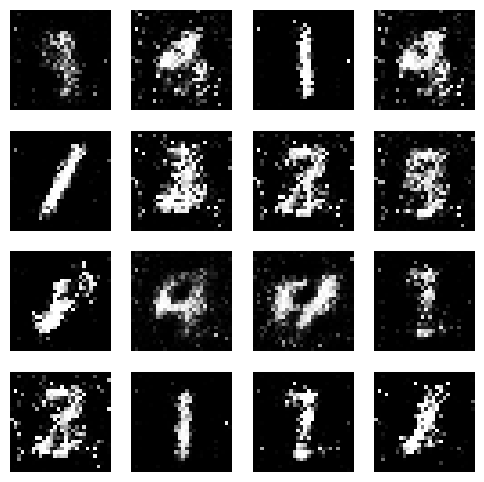

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 1: Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# Step 2: Define Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Step 3: Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

# Step 4: Loss + Optimizers
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

# Step 5: Training Loop
epochs = 55

for epoch in range(epochs):
    for real, _ in loader:

        real = real.view(-1, 28*28).to(device)
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        D_loss = criterion(D(real), real_labels) + criterion(D(fake.detach()), fake_labels)

        opt_D.zero_grad()
        D_loss.backward()
        opt_D.step()

        # ---- Train Generator ----
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        G_loss = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

# Step 6: Generate Digits
z = torch.randn(16, 100).to(device)
samples = G(z).view(-1, 28, 28).detach().cpu()

# Plot Generated Digits
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap="gray")
    plt.axis("off")
plt.show()

Epoch [1/50] | D Loss: 0.1185 | G Loss: 6.8244
Epoch [2/50] | D Loss: 0.0230 | G Loss: 7.0286
Epoch [3/50] | D Loss: 0.2106 | G Loss: 6.9570
Epoch [4/50] | D Loss: 0.3833 | G Loss: 4.9680
Epoch [5/50] | D Loss: 0.6474 | G Loss: 3.0963
Epoch [6/50] | D Loss: 1.0700 | G Loss: 3.2339
Epoch [7/50] | D Loss: 0.4879 | G Loss: 3.1820
Epoch [8/50] | D Loss: 1.3137 | G Loss: 2.4222
Epoch [9/50] | D Loss: 0.6807 | G Loss: 2.3896
Epoch [10/50] | D Loss: 0.8467 | G Loss: 3.0420
Epoch [11/50] | D Loss: 0.4609 | G Loss: 2.8493
Epoch [12/50] | D Loss: 0.3397 | G Loss: 3.3179
Epoch [13/50] | D Loss: 0.5405 | G Loss: 3.9712
Epoch [14/50] | D Loss: 0.4942 | G Loss: 3.1996
Epoch [15/50] | D Loss: 0.7142 | G Loss: 3.0720
Epoch [16/50] | D Loss: 0.4172 | G Loss: 7.4559
Epoch [17/50] | D Loss: 0.4894 | G Loss: 4.8458
Epoch [18/50] | D Loss: 0.5226 | G Loss: 5.4508
Epoch [19/50] | D Loss: 0.7458 | G Loss: 3.9627
Epoch [20/50] | D Loss: 1.1213 | G Loss: 6.1734
Epoch [21/50] | D Loss: 0.2266 | G Loss: 5.2079
E

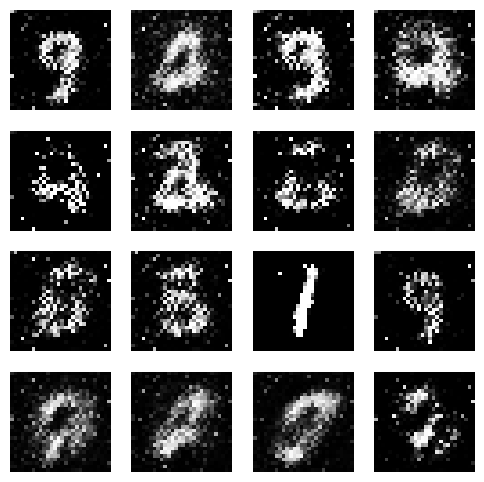

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 1: Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# Step 2: Define Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Step 3: Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

# Step 4: Loss + Optimizers
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

# Step 5: Training Loop
epochs = 50

for epoch in range(epochs):
    for real, _ in loader:

        real = real.view(-1, 28*28).to(device)
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        D_loss = criterion(D(real), real_labels) + criterion(D(fake.detach()), fake_labels)

        opt_D.zero_grad()
        D_loss.backward()
        opt_D.step()

        # ---- Train Generator ----
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        G_loss = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

# Step 6: Generate Digits
z = torch.randn(16, 100).to(device)
samples = G(z).view(-1, 28, 28).detach().cpu()

# Plot Generated Digits
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap="gray")
    plt.axis("off")
plt.show()